In [23]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
plt.style.use('ggplot')
%matplotlib inline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

Задание 3.1

In [24]:
def generate_data(n_points=20):
  """
    Принимает на вход n_points точек
    Возвращает данные для обучения и теста
  """
  X = np.linspace(-5, 5, n_points)
  y = 10 * X - 7

  X_train = X[0::2].reshape(-1, 1)
  y_train = y[0::2] + np.random.randn(int(n_points/2)) * 10

  X_test = X[1::2].reshape(-1, 1)
  y_test = y[1::2] + np.random.randn(int(n_points/2)) * 10

  print(f'Generated {len(X_train)} train samples and {len(X_test)} test samples')
  return X, X_train, y_train, X_test, y_test

In [ ]:
X, X_train, y_train, X_test, y_test = generate_data(100)

Generated 50 train samples and 50 test samples


In [25]:
X_train_with_bias = np.column_stack((np.ones(len(X_train)), X_train))

In [26]:
weights = np.linalg.inv(X_train_with_bias.T @ X_train_with_bias) @ X_train_with_bias.T @ y_train

In [27]:
b_manual = weights[0]
w1_manual = weights[1]

In [28]:
print(f"  Вес (w1) = {w1_manual:.4f} (10 из ф. generate_data)")
print(f"  Смещение (b) = {b_manual:.4f}(7 из ф. generate_data)")



  Вес (w1) = 10.2059 (10 из ф. generate_data)
  Смещение (b) = -3.4237(7 из ф. generate_data)


In [29]:
y_train_pred_manual = w1_manual * X_train.flatten() + b_manual
y_test_pred_manual = w1_manual * X_test.flatten() + b_manual

In [31]:
mae_train = mean_absolute_error(y_train, y_train_pred_manual)
mse_train = mean_squared_error(y_train, y_train_pred_manual)
mae_test = mean_absolute_error(y_test, y_test_pred_manual)
mse_test = mean_squared_error(y_test, y_test_pred_manual)

print(f"  Train MSE = {mse_train:.4f}")
print(f"  Train MAE = {mae_train:.4f}")
print(f"  Test MSE  = {mse_test:.4f}")
print(f"  Test MAE  = {mae_test:.4f}")

  Train MSE = 107.5631
  Train MAE = 8.4591
  Test MSE  = 90.9826
  Test MAE  = 7.5237


СРАВНЕНИЕ С SKLEARN

In [32]:
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)

print(f"  Вес (coef_) = {sklearn_model.coef_[0]:.4f}")
print(f"  Смещение (intercept_) = {sklearn_model.intercept_:.4f}")

  Вес (coef_) = 10.2059
  Смещение (intercept_) = -3.4237


In [34]:
y_test_pred_sklearn = sklearn_model.predict(X_test)

mae_test_sklearn = mean_absolute_error(y_test, y_test_pred_sklearn)
mse_test_sklearn = mean_squared_error(y_test, y_test_pred_sklearn)

print(f"  MSE (ручной): {mse_test:.4f} vs MSE (sklearn): {mse_test_sklearn:.4f}")
print(f"  MAE (ручной): {mae_test:.4f} vs MAE (sklearn): {mae_test_sklearn:.4f}")


Сравнение метрик на тестовой выборке:
  MSE (ручной): 90.9826 vs MSE (sklearn): 90.9826
  MAE (ручной): 7.5237 vs MAE (sklearn): 7.5237


## Задание 3.2

In [35]:
def generate_wave_set(n_support=1000, n_train=25, std=0.3):
    data = {}
    # выберем некоторое количество точек из промежутка от 0 до 2*pi
    data['support'] = np.linspace(0, 2*np.pi, num=n_support)
    # для каждой посчитаем значение sin(x) + 1
    # это будет ground truth
    data['values'] = np.sin(data['support']) + 1
    # из support посемплируем некоторое количество точек с возвратом, это будут признаки
    data['x_train'] = np.sort(np.random.choice(data['support'], size=n_train, replace=True))
    # опять посчитаем sin(x) + 1 и добавим шум, получим целевую переменную
    data['y_train'] = np.sin(data['x_train']) + 1 + np.random.normal(0, std, size=data['x_train'].shape[0])
    return data

data = generate_wave_set(1000, 250)

In [43]:
X_train = data['x_train'].reshape(-1, 1)  # Признак (x координата)
y_train = data['y_train']                  # Целевая переменная (sin(x) + 1 + шум)
X_support = data['support'].reshape(-1, 1) # Опорные точки для проверки
y_true = data['values']                    # Истинные значения (без шума)

In [44]:
X_train_with_bias = np.column_stack((np.ones(len(X_train)), X_train))
weights = np.linalg.inv(X_train_with_bias.T @ X_train_with_bias) @ X_train_with_bias.T @ y_train
b_linear = weights[0]
w1_linear = weights[1]
print(f"  Вес (w1) = {w1_linear:.4f}")
print(f"  Смещение (b) = {b_linear:.4f}")
print(f"\nПолучили уравнение прямой: y = {w1_linear:.4f}*x + {b_linear:.4f}")

  Вес (w1) = -0.2990
  Смещение (b) = 1.8981

Получили уравнение прямой: y = -0.2990*x + 1.8981


In [45]:
y_train_pred_linear = w1_linear * X_train.flatten() + b_linear
y_support_pred_linear = w1_linear * X_support.flatten() + b_linear

In [46]:
mae_train = mean_absolute_error(y_train, y_train_pred_linear)
mse_train = mean_squared_error(y_train, y_train_pred_linear)
mae_support = mean_absolute_error(y_true, y_support_pred_linear)
mse_support = mean_squared_error(y_true, y_support_pred_linear)

print(f"  Train MSE = {mse_train:.4f}")
print(f"  Train MAE = {mae_train:.4f}")
print(f"  Support MSE = {mse_support:.4f}")
print(f"  Support MAE = {mae_support:.4f}")

  Train MSE = 0.2851
  Train MAE = 0.4488
  Support MSE = 0.1985
  Support MAE = 0.3929


## Задание 3.3

yˆ=w1x1+w2x21+...+wkxk1+b,

In [50]:
from sklearn.preprocessing import PolynomialFeatures

In [51]:
models = {}
predictions = {}
mses = {}

In [ ]:
degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

for degree in degrees:
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly_features.fit_transform(X_train)
    X_support_poly = poly_features.transform(X_support)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_train_pred = model.predict(X_train_poly)
    y_support_pred = model.predict(X_support_poly)
    
    models[degree] = model
    predictions[degree] = y_support_pred
    
    mse = mean_squared_error(y_true, y_support_pred)
    mses[degree] = mse
    
    print(f"Степень {degree:2d}: MSE = {mse:.6f}, Коэффициентов: {len(model.coef_)+1}")

Степень  1: MSE = 0.198504, Коэффициентов: 2
Степень  2: MSE = 0.198859, Коэффициентов: 3
Степень  3: MSE = 0.006076, Коэффициентов: 4
Степень  4: MSE = 0.006252, Коэффициентов: 5
Степень  5: MSE = 0.001432, Коэффициентов: 6
Степень  6: MSE = 0.001651, Коэффициентов: 7
Степень  7: MSE = 0.003460, Коэффициентов: 8
Степень  8: MSE = 0.012967, Коэффициентов: 9
Степень  9: MSE = 0.040502, Коэффициентов: 10
Степень 10: MSE = 0.037362, Коэффициентов: 11


In [54]:
best_degree = min(mses, key=mses.get)
print(f"\nПолином степени {best_degree} дает наименьшую ошибку MSE = {mses[best_degree]:.6f}")



Полином степени 5 дает наименьшую ошибку MSE = 0.001432


Визуализация

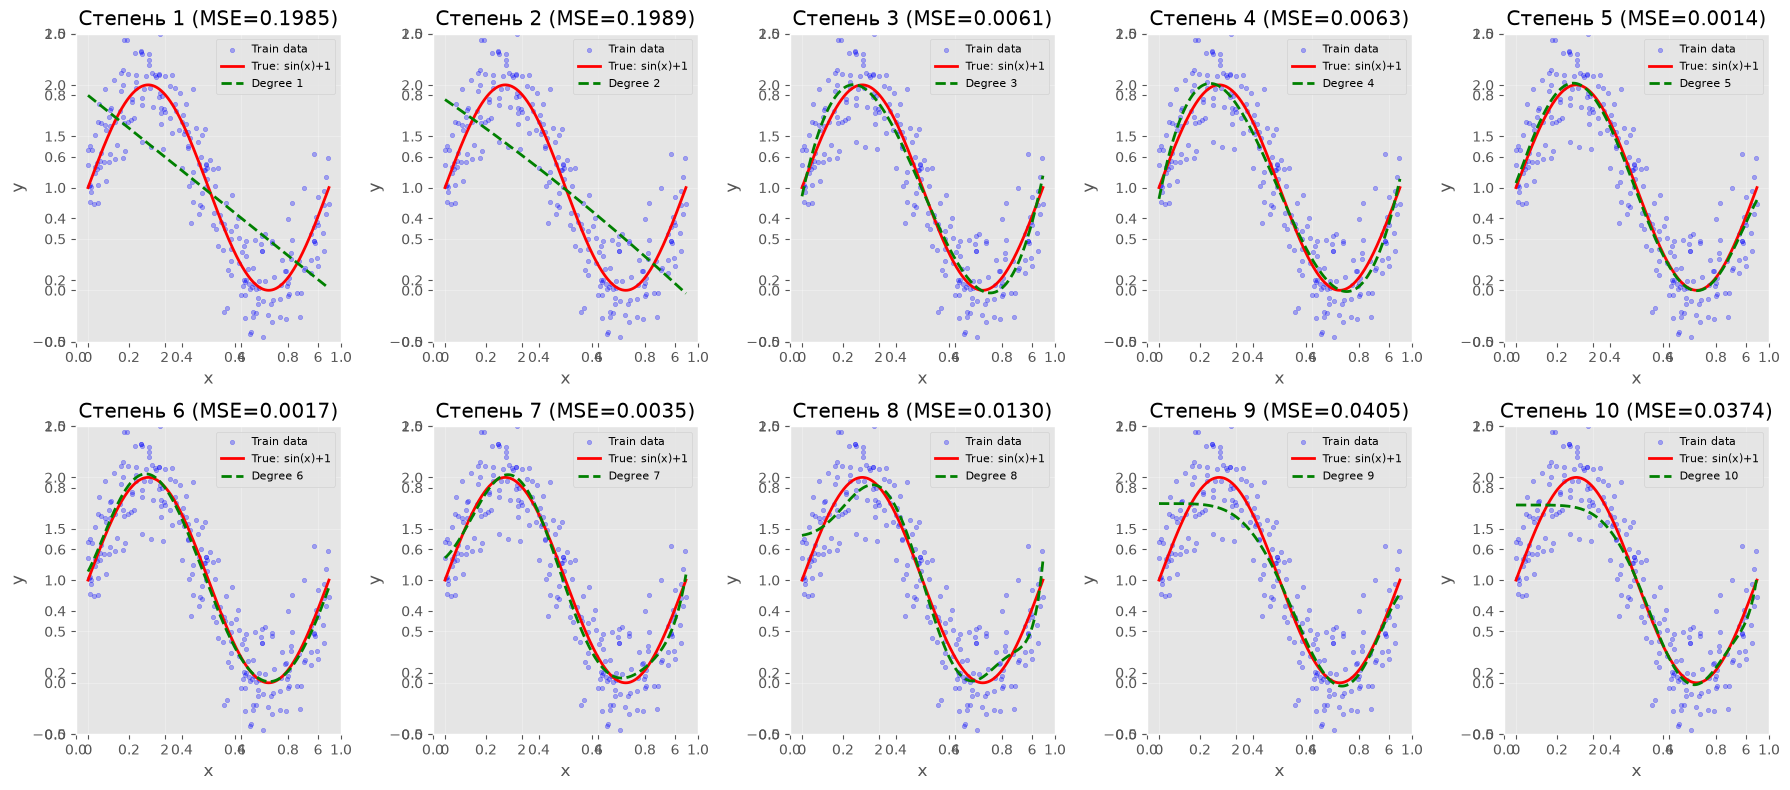

In [60]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, degree in enumerate(degrees[:10], 1):  # Первые 10 степеней
    ax = fig.add_subplot(2, 5, i)  # Исправлено: 2 строки, 5 столбцов
    
    # Обучающие точки
    ax.scatter(X_train, y_train, alpha=0.3, s=10, color='blue', label='Train data')
    
    # Истинная функция
    ax.plot(X_support, y_true, 'r-', linewidth=2, label='True: sin(x)+1')
    
    # Предсказание модели
    ax.plot(X_support, predictions[degree], 'g--', linewidth=2, label=f'Degree {degree}')
    
    ax.set_title(f'Степень {degree} (MSE={mses[degree]:.4f})')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_ylim(-0.5, 2.5)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1. Степень 1-2 (линейные):
   MSE ~ 0.199  

   Прямая линия не может описать синусоиду => очень большая ошибка


2. Степени 3-4:
   Значительно уменьшается MSE ~ 0.006 

   Полином приближается к форме синусоиды


3. Степень 5 (ОПТИМАЛЬНАЯ):
   MSE = 0,0014 (наименьшая)

   Достаточно гибкий, чтобы описать синусоиду

   Не переобучается под шум


4. Степени 7-10:
   MSE растет. 
   
   Модель пытается описать каждый случайный шум в данных в итоге переобучается

   
Вывод: 5 подходит лучше всего, т.к. у него наименьшая MSE, полином может описать синусоиду, модель достаточно простая, чтобы не подстраиваться под случайный шум 

## Задание 3.4 

- оставьте в наборе данных только 7 наиболее значимых признаков
- настройте параметры линейной регрессии и сравните метрики качества (MSE и MAE) для полного датасета и усечённого

In [81]:
house_data = pd.read_csv('boston.csv')

print(f"\nРазмер датасета: {house_data.shape}")
print(f"Колонки: {house_data.columns.tolist()}")
print(house_data.head())

print(f"\nПропущенные значения:")
print(house_data.isnull().sum())


Размер датасета: (506, 14)
Колонки: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  

Пропущенные значения:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: in

Я взяла данные https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data. Это очищенная версия данных от другого пользователя. Я использовала её, т.к. в описании основного датасета происходит какая-то путаница 

Attribute Information
Input features in order:
1) CRIM: per capita crime rate by town
2) ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
3) INDUS: proportion of non-retail business acres per town
4) CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
5) NOX: nitric oxides concentration (parts per 10 million) [parts/10M]
6) RM: average number of rooms per dwelling
7) AGE: proportion of owner-occupied units built prior to 1940
8) DIS: weighted distances to five Boston employment centres
9) RAD: index of accessibility to radial highways
10) TAX: full-value property-tax rate per $10,000 [$/10k]
11) PTRATIO: pupil-teacher ratio by town
12) B: The result of the equation B=1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
13) LSTAT: % lower status of the population

Output variable:
1) MEDV: Median value of owner-occupied homes in $1000's [k$]

In [84]:
target_column = 'MEDV'
X = house_data.drop(columns=[target_column])
y = house_data[target_column]

In [100]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

selector = SelectKBest(score_func=f_regression, k=7)
selector.fit(X, y)

SelectKBest(k=7, score_func=<function f_regression at 0x000001E1A8130E00>)

In [101]:
selected_features = X.columns[selector.get_support()].tolist()

X_selected = X[selected_features]

1. Разделить на две выборки
2. Усреднить от 0 до 1
3. Произвести модель
4. Сделать предсказания
5. Вычислить mse и mae

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

In [103]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [104]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[-0.69, 0.77,-0.33,...,-0.4 ,-1.82,-3.74]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,7
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[39. ,20.07,18.72,...,11.22, 9.98, 8.86]"


In [105]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)


In [107]:
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"\nУРЕЗАННЫЙ ДАТАСЕТ")
print(f"\nТренировочная выборка:")
print(f"  MSE: {mse_train:.4f}")
print(f"  MAE: {mae_train:.4f}")
print(f"\nТестовая выборка:")
print(f"  MSE: {mse_test:.4f}")
print(f"  MAE: {mae_test:.4f}")



УРЕЗАННЫЙ ДАТАСЕТ

Тренировочная выборка:
  MSE: 26.5672
  MAE: 3.5909

Тестовая выборка:
  MSE: 28.4317
  MAE: 3.4174


In [111]:
X_full_train, X_full_test, y_full_train, y_full_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_full = StandardScaler()
X_full_train_scaled = scaler_full.fit_transform(X_full_train)
X_full_test_scaled = scaler_full.transform(X_full_test)

model_full = LinearRegression()
model_full.fit(X_full_train_scaled, y_full_train)
y_full_test_pred = model_full.predict(X_full_test_scaled)

mse_test_full = mean_squared_error(y_full_test, y_full_test_pred)
mae_test_full = mean_absolute_error(y_full_test, y_full_test_pred)

print(f"\nПОЛНЫЙ ДАТАСЕТ:")
print(f"\nТестовая выборка:")
print(f"  MSE: {mse_test_full:.4f}")
print(f"  MAE: {mae_test_full:.4f}")


ПОЛНЫЙ ДАТАСЕТ:

Тестовая выборка:
  MSE: 24.2911
  MAE: 3.1891


In [113]:
print(f"\nУлучшение MSE: {(mse_test_full - mse_test) / mse_test_full :+.2f}")
print(f"Улучшение MAE: {(mae_test_full - mae_test) / mae_test_full :+.2f}")



Улучшение MSE: -0.17
Улучшение MAE: -0.07


=> Полный датасет работает лучше усеченного